week11課題

In [1]:
%pip install ultralytics dill opencv-python matplotlib facenet-pytorch mtcnn
# 必要なライブラリを一度にインストールします（ノートブック内で実行）。

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


画像はrandomに貼ってありました一番最初にとった集合写真を使わせていただきました。

検出された顔の数: 82 faces


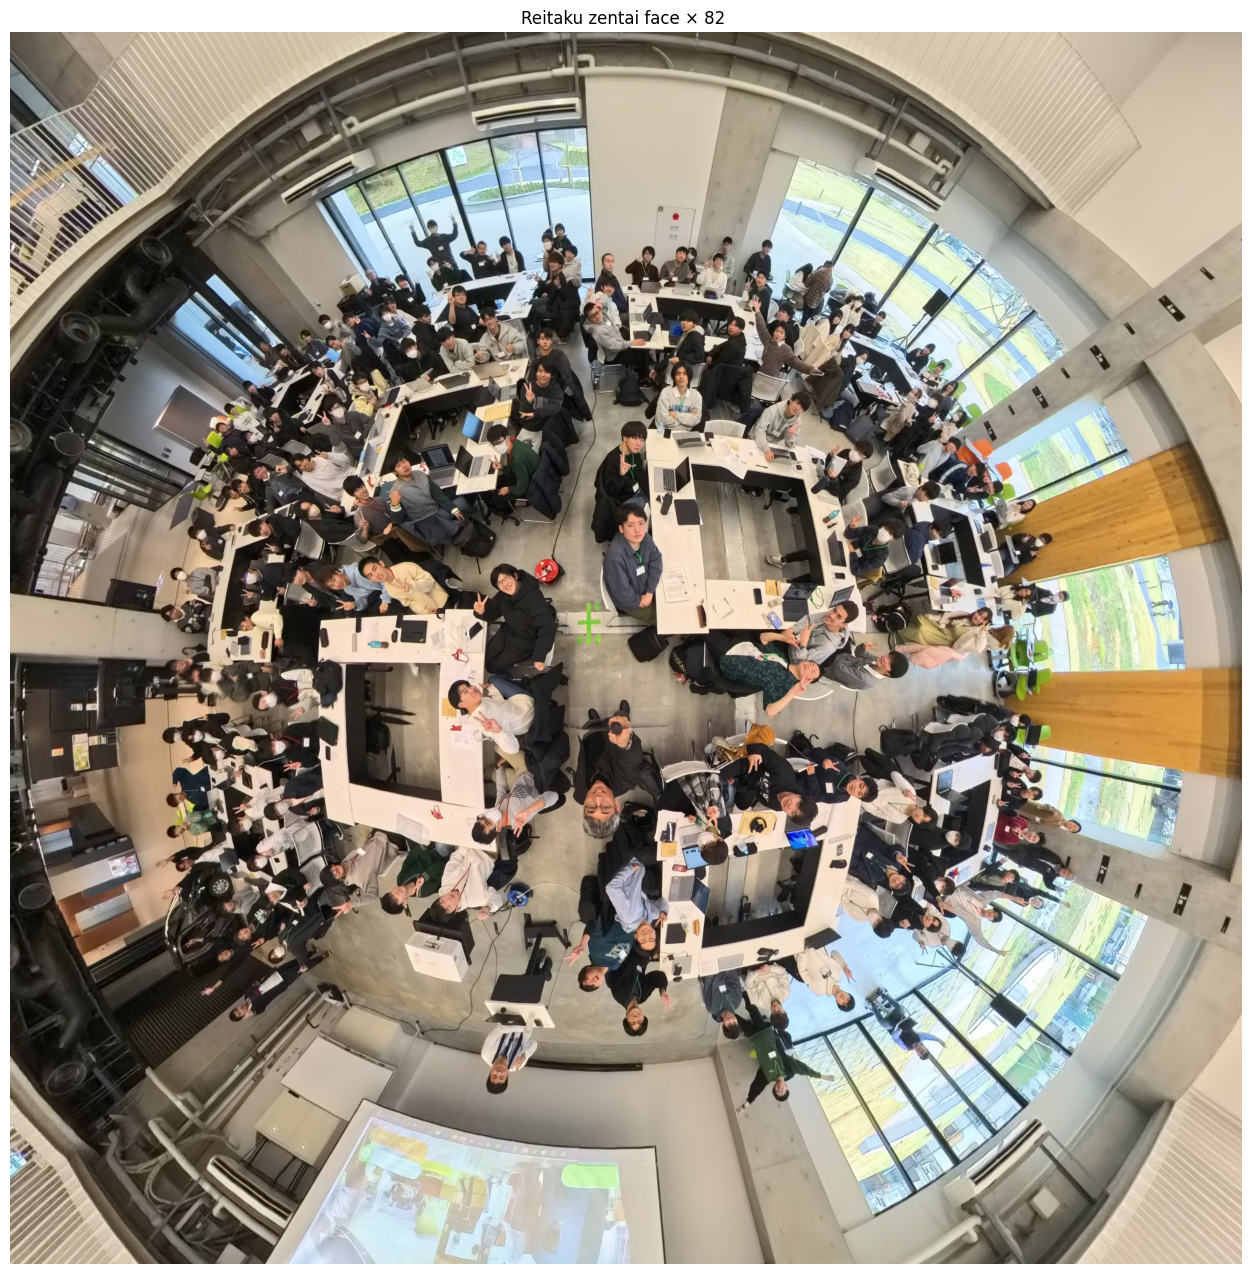

In [2]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("reitaku.zentai.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 高解像度で保存（アップスケールして保存）
output_path = Path("reitaku.zentai.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Reitaku zentai face × {len(result.boxes)} ')
plt.show()

遠くにいた人の画質が悪かったからか実際の人数より少ない数しか検出されませんでした。

なのでChatGPTを使って修正の案を出してもらいました,,,がどれを試しても特に変わらなかったので諦めます。